# Chapter 97 — Line Equations

> **Prerequisites:** ch096 (Slopes and Lines)
>
> **Outcomes:** Write line equations in slope-intercept, point-slope, and standard form; Convert between forms; Find line through two points; Connect to linear classifiers in ML


## Three Forms of a Line

A line in 2D can be written in three equivalent forms:

**Slope-intercept:** y = mx + b
- m: slope, b: y-intercept
- Easy to plot and interpret

**Point-slope:** y - y₁ = m(x - x₁)
- Useful when you know a point (x₁, y₁) and slope m

**Standard (implicit):** ax + by + c = 0
- Handles vertical lines (a=1, b=0, c=-k)
- Generalization: in N dimensions, aᵀx + c = 0 is a hyperplane

**From two points:** Given P₁, P₂:
m = (y₂-y₁)/(x₂-x₁)
b = y₁ - m·x₁

Through (1, 2) and (4, 8):
  Slope-intercept: y = 2.0x + 0.0
  Standard form:   -2.0x + 1y + -0.0 = 0


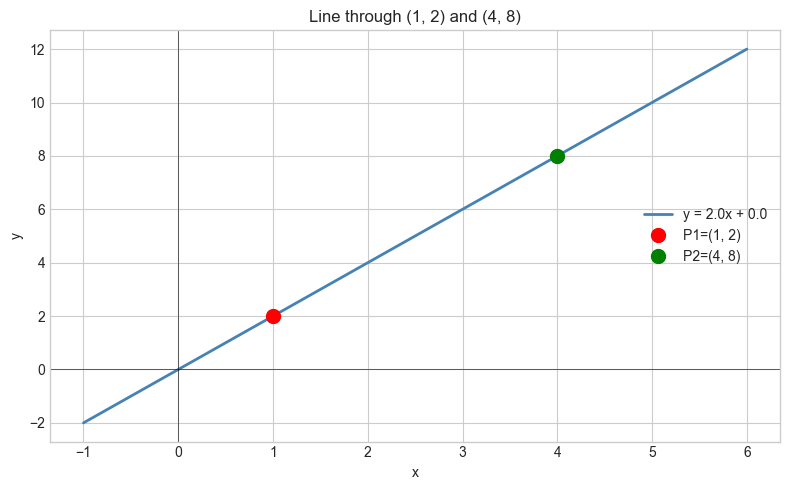

In [2]:
# --- Line equations ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def line_through_points(p1, p2):
    """Returns (m, b) for y = mx + b through p1, p2."""
    x1,y1 = p1; x2,y2 = p2
    if abs(x2-x1) < 1e-12: raise ValueError("Vertical line")
    m = (y2-y1)/(x2-x1)
    b = y1 - m*x1
    return m, b

def line_to_standard(m, b):
    """y = mx + b → -mx + y - b = 0  i.e. a=-m, b=1, c=-b"""
    return -m, 1, -b

P1, P2 = (1, 2), (4, 8)
m, b = line_through_points(P1, P2)
a, bcoef, c = line_to_standard(m, b)

print(f"Through {P1} and {P2}:")
print(f"  Slope-intercept: y = {m}x + {b}")
print(f"  Standard form:   {a}x + {bcoef}y + {c} = 0")

x = np.linspace(-1, 6, 100)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, m*x+b, 'steelblue', linewidth=2, label=f'y = {m}x + {b}')
ax.plot(*P1, 'ro', markersize=10, label=f'P1={P1}'); ax.plot(*P2, 'go', markersize=10, label=f'P2={P2}')
ax.axhline(0, color='black', linewidth=0.4); ax.axvline(0, color='black', linewidth=0.4)
ax.set_title(f'Line through {P1} and {P2}'); ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## Lines as Classifiers

A linear classifier draws a line (in 2D) or hyperplane (in N-D) that separates two classes.

The decision rule: classify point P as class +1 if ax + by + c > 0, else class -1.
This is exactly the standard form equation — the sign of ax + by + c tells which side of the line P is on.

In logistic regression: P(y=1) = sigmoid(wᵀx + b) where wᵀx + b = 0 is the decision boundary.
The line wᵀx + b = 0 is the standard form equation in N dimensions.

*(Logistic regression built from scratch in ch229; hyperplanes in ch163.)*

## Exercises

**Easy 1.** Write the equation of the line through (0,3) with slope -2.
**Easy 2.** Find the y-intercept of the line through (2,5) and (6,9).
**Medium 1.** Implement `point_to_line_distance(point, line_abc)` — the perpendicular distance from a point to a line given in standard form: d = |ax₀ + by₀ + c| / √(a²+b²).
**Hard.** Implement a perceptron: update w = w + y·x when sign(wᵀx) ≠ y. Show convergence on linearly separable data.

## Summary

- Three forms: slope-intercept (y=mx+b), point-slope, standard (ax+by+c=0)
- Standard form generalizes to hyperplanes in N-D: aᵀx + c = 0
- Sign of ax+by+c tells which side of the line a point is on → linear classifier

**Forward:** ch098 (Intersections) finds where lines cross; ch163 (Linear Transformations) uses hyperplanes.